In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("cs-training.csv", index_col=0)

In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (150000, 11)


In [5]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
baseline_default_rate = df['SeriousDlqin2yrs'].mean()

In [7]:
print(f"Default Rate: {baseline_default_rate:.2%}")

Default Rate: 6.68%


In [8]:
print("--- Missing Values Summary ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Missing Values Summary ---
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [9]:
# 3. Train / Test Split (Stratified to preserve class imbalance)
# In credit risk modeling, we split prior to preprocessing to avoid data leakage
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [11]:
# 4. Data Cleaning & Anomaly Handling
# In this dataset, age == 0 is an impossible entry (often 1 record); replace with median age
median_age = X_train.loc[X_train["age"] > 0, "age"].median()
X_train["age"] = X_train["age"].replace(0, median_age)
X_test["age"] = X_test["age"].replace(0, median_age)

In [12]:
# 5. Missing Value Indicator Flags
# In credit underwriting, the absence of data (e.g., unreported income) is a risk signal in itself
X_train["MonthlyIncome_Missing"] = (
    X_train["MonthlyIncome"].isnull().astype(int)
)
X_test["MonthlyIncome_Missing"] = X_test["MonthlyIncome"].isnull().astype(int)

X_train["NumberOfDependents_Missing"] = (
    X_train["NumberOfDependents"].isnull().astype(int)
)
X_test["NumberOfDependents_Missing"] = (
    X_test["NumberOfDependents"].isnull().astype(int)
)

In [13]:
# 6. Imputation using Training Medians (Prevent Data Leakage)
monthly_income_median = X_train["MonthlyIncome"].median()
dependents_median = X_train["NumberOfDependents"].median()

X_train["MonthlyIncome"] = X_train["MonthlyIncome"].fillna(
    monthly_income_median
)
X_test["MonthlyIncome"] = X_test["MonthlyIncome"].fillna(monthly_income_median)

X_train["NumberOfDependents"] = X_train["NumberOfDependents"].fillna(
    dependents_median
)
X_test["NumberOfDependents"] = X_test["NumberOfDependents"].fillna(
    dependents_median
)

In [14]:
# 7. Verification Check
print("\n--- Remaining Nulls in Training Set ---")
print(X_train.isnull().sum().sum())
print("--- Remaining Nulls in Test Set ---")
print(X_test.isnull().sum().sum())


--- Remaining Nulls in Training Set ---
0
--- Remaining Nulls in Test Set ---
0


In [15]:
def calculate_woe_iv(df, feature, target, bins=10):
    """Calculates WOE and IV for a continuous feature."""
    # Create a working dataframe
    data = df[[feature, target]].copy()
    
    # Bin the continuous feature into quantiles
    # duplicates='drop' handles features with many identical values (e.g., many 0s)
    data['binned'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    
    # Calculate Good and Bad counts per bin
    # In this dataset, SeriousDlqin2yrs = 1 is "Bad" (Default), 0 is "Good"
    grouped = data.groupby('binned', observed=False).agg(
        Bads=(target, 'sum'),
        Total=(target, 'count')
    )
    grouped['Goods'] = grouped['Total'] - grouped['Bads']
    
    # Add 0.0001 to prevent division by zero
    total_goods = grouped['Goods'].sum()
    total_bads = grouped['Bads'].sum()
    
    grouped['%_Goods'] = (grouped['Goods'] + 0.0001) / total_goods
    grouped['%_Bads'] = (grouped['Bads'] + 0.0001) / total_bads
    
    # Calculate WOE and IV
    grouped['WOE'] = np.log(grouped['%_Goods'] / grouped['%_Bads'])
    grouped['IV'] = (grouped['%_Goods'] - grouped['%_Bads']) * grouped['WOE']
    
    iv_total = grouped['IV'].sum()
    
    return grouped[['WOE', 'IV']], iv_total, grouped['WOE'].to_dict()

# 1. Combine X_train and y_train temporarily for the calculation
train_data = X_train.copy()
train_data['target'] = y_train

# 2. Select continuous features to bin (exclude the missing flags)
continuous_features = [col for col in X_train.columns if 'missing' not in col]

# 3. Calculate IV for all features and store WOE mappings
iv_summary = {}
woe_mappings = {}

for feature in continuous_features:
    woe_df, iv_val, woe_dict = calculate_woe_iv(train_data, feature, 'target')
    iv_summary[feature] = iv_val
    woe_mappings[feature] = woe_dict

# 4. Display features sorted by Information Value
iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
print("Information Value (IV) by Feature:")
print(iv_df)

Information Value (IV) by Feature:
                                                IV
RevolvingUtilizationOfUnsecuredLines  1.110987e+00
NumberOfTime30-59DaysPastDueNotWorse  4.683217e-01
age                                   2.462705e-01
DebtRatio                             7.356111e-02
MonthlyIncome                         7.290549e-02
NumberOfOpenCreditLinesAndLoans       6.879273e-02
NumberOfDependents                    2.430823e-02
NumberRealEstateLoansOrLines          1.353648e-02
NumberOfTimes90DaysLate               1.339632e-16
NumberOfTime60-89DaysPastDueNotWorse  1.339632e-16
MonthlyIncome_Missing                 1.339632e-16
NumberOfDependents_Missing            1.339632e-16


In [16]:
import statsmodels.api as sm
from xgboost import XGBClassifier
# 1. Feature Selection based on IV > 0.02
selected_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents'
]

# 2. Map WOE to the Training Set
X_train_woe = pd.DataFrame(index=X_train.index)

for feature in selected_features:
    # Re-apply the exact quantile bins to map the WOE values
    bins = pd.qcut(X_train[feature], q=10, duplicates='drop')
    X_train_woe[f'{feature}_WOE'] = bins.map(woe_mappings[feature])

# Statsmodels requires us to explicitly add a constant for the intercept
X_train_woe = sm.add_constant(X_train_woe)

# 3. Fit the Champion Scorecard (Logistic Regression)
print("--- Training Champion Model (Logistic Regression) ---")
logit_model = sm.Logit(y_train, X_train_woe.astype(float))
champion_result = logit_model.fit()
print(champion_result.summary())

# 4. Fit the Challenger Model (XGBoost)
print("\n--- Training Challenger Model (XGBoost) ---")
# Calculate the optimal weight for the minority class (Defaults)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

challenger_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='auc',
    max_depth=4, # Kept shallow to prevent heavy overfitting on imbalanced data
    learning_rate=0.1
)

# Note: XGBoost uses the raw, un-binned data (X_train) including missing flags
challenger_model.fit(X_train, y_train)
print("XGBoost training complete.")

--- Training Champion Model (Logistic Regression) ---
Optimization terminated successfully.
         Current function value: 0.200208
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120000
Model:                          Logit   Df Residuals:                   119992
Method:                           MLE   Df Model:                            7
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.1841
Time:                        15:41:56   Log-Likelihood:                -24025.
converged:                       True   LL-Null:                       -29447.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [17]:
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import numpy as np

# 1. Map Test Data to Training WOE Bins
X_test_woe = pd.DataFrame(index=X_test.index)

for feature in selected_features:
    X_test_woe[f'{feature}_WOE'] = 0.0 # Initialize column
    intervals = list(woe_mappings[feature].keys())
    
    for interval in intervals:
        # Check if test values fall within the train interval
        mask = (X_test[feature] > interval.left) & (X_test[feature] <= interval.right)
        X_test_woe.loc[mask, f'{feature}_WOE'] = woe_mappings[feature][interval]
    
    # Handle edge cases (test values lower/higher than any train data)
    min_interval = min(intervals, key=lambda x: x.left)
    max_interval = max(intervals, key=lambda x: x.right)
    
    X_test_woe.loc[X_test[feature] <= min_interval.left, f'{feature}_WOE'] = woe_mappings[feature][min_interval]
    X_test_woe.loc[X_test[feature] > max_interval.right, f'{feature}_WOE'] = woe_mappings[feature][max_interval]

X_test_woe = sm.add_constant(X_test_woe)

# 2. Generate Predicted Probabilities
# Champion (Statsmodels Logit returns probability of class 1 directly)
champ_preds = champion_result.predict(X_test_woe.astype(float))

# Challenger (Scikit-learn API returns probabilities for class [0, 1])
# We slice [:, 1] to get the probability of default
challenger_preds = challenger_model.predict_proba(X_test)[:, 1]

# 3. Calculate ROC-AUC
champ_auc = roc_auc_score(y_test, champ_preds)
challenger_auc = roc_auc_score(y_test, challenger_preds)

# 4. Calculate KS Statistic (Max distance between CDF of goods and bads)
champ_ks = ks_2samp(champ_preds[y_test == 1], champ_preds[y_test == 0]).statistic
challenger_ks = ks_2samp(challenger_preds[y_test == 1], challenger_preds[y_test == 0]).statistic

print("--- Model Validation Metrics ---")
print(f"Champion (Logistic) ROC-AUC : {champ_auc:.4f}")
print(f"Challenger (XGBoost) ROC-AUC: {challenger_auc:.4f}")
print("-" * 30)
print(f"Champion (Logistic) KS Stat : {champ_ks:.4f}")
print(f"Challenger (XGBoost) KS Stat: {challenger_ks:.4f}")

--- Model Validation Metrics ---
Champion (Logistic) ROC-AUC : 0.8178
Challenger (XGBoost) ROC-AUC: 0.8694
------------------------------
Champion (Logistic) KS Stat : 0.5004
Challenger (XGBoost) KS Stat: 0.5846


Generating SHAP Summary Plot (Global Feature Importance)...


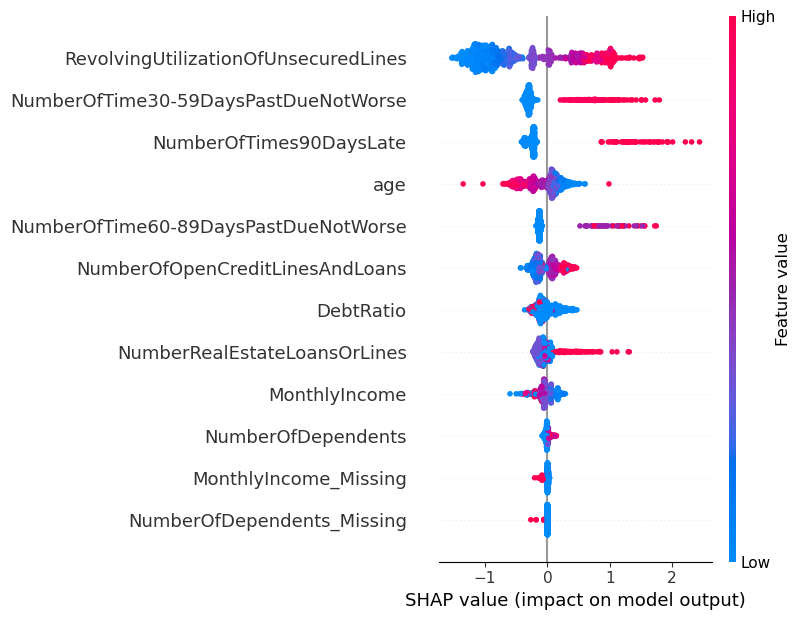


Analyzing Customer Index 3 with PD: 86.12%


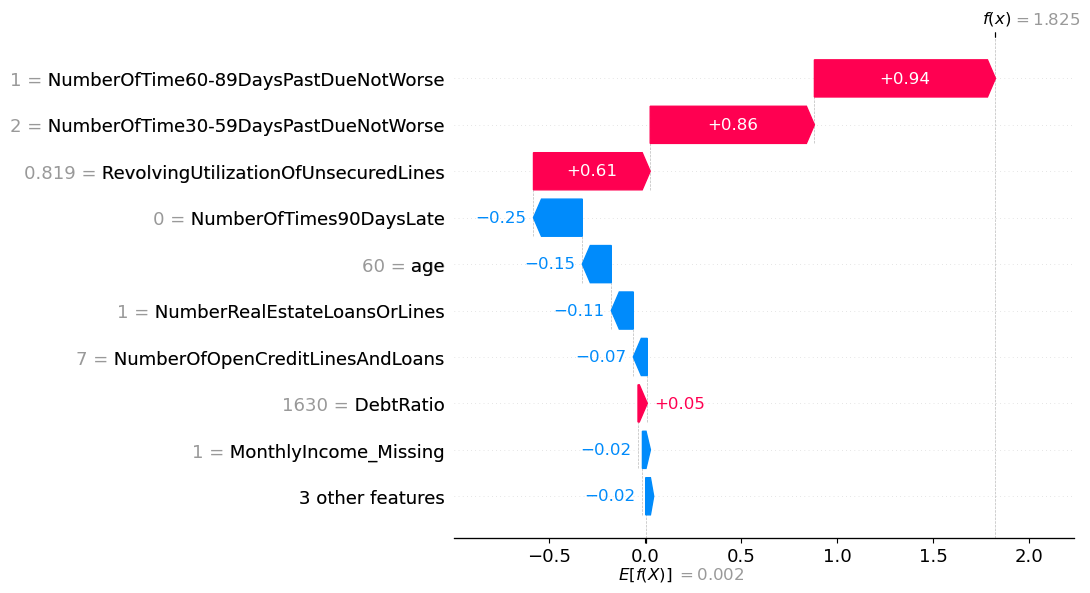

In [35]:
import shap
import numpy as np
import pandas as pd

# 1. Initialize the TreeExplainer with your trained XGBoost model
explainer = shap.TreeExplainer(challenger_model)

# For performance in this notebook, we'll explain a sample of the test set
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer(X_test_sample)

# 2. Global Interpretability: Summary Plot
# This shows feature importance across the entire portfolio
print("Generating SHAP Summary Plot (Global Feature Importance)...")
shap.summary_plot(shap_values, X_test_sample)

# 3. Find a high-risk customer (Probability of Default > 0.70)
# We will use this customer to simulate an adverse action scenario
sample_probs = challenger_model.predict_proba(X_test_sample)[:, 1]
high_risk_idx = np.where(sample_probs > 0.70)[0][0]
high_risk_customer_data = X_test_sample.iloc[[high_risk_idx]]
high_risk_prob = sample_probs[high_risk_idx]

print(f"\nAnalyzing Customer Index {high_risk_idx} with PD: {high_risk_prob:.2%}")

# 4. Local Interpretability: Waterfall Plot for the single customer
# This visualizes exactly how we arrived at this specific customer's score
shap_values_single = explainer(high_risk_customer_data)
shap.plots.waterfall(shap_values_single[0])